Skin Tone Based Fashion Recommendation - Google Colab Notebook

In [ ]:
# --- 📦 IMPORT LIBRARY ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab import files
from PIL import Image
import io

upload face image

In [ ]:
# --- 🖼️ UPLOAD IMAGE ---
uploaded = files.upload()
for fn in uploaded.keys():
    image_path = fn

Saving IMG_3926.jpg to IMG_3926.jpg


FUNCTION UNTUK EKSTRAK WARNA DOMINAN

In [ ]:
# --- 🎯 FUNCTION UNTUK EKSTRAK WARNA DOMINAN ---
def get_dominant_color(image, k=3):
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img = img.reshape((-1, 3))
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(img)
    dominant = kmeans.cluster_centers_[kmeans.labels_].mean(axis=0).astype(int)
    return dominant

MAPPING SKIN TONE COLOR CODE

In [ ]:
# --- 🎯 SKIN TONE MAPPING ---
skin_tone_map = {
    "#373028": "Deepest Skin",
    "#422811": "Very Deep",
    "#513B2E": "Deep Brown",
    "#6F503C": "Medium Brown",
    "#81654F": "Tan",
    "#9D7A54": "Light Tan",
    "#BEA07E": "Medium Fair",
    "#E5C8A6": "Light Fair",
    "#E7C1B8": "Warm Fair",
    "#F3DAD6": "Very Fair",
    "#FBF2F3": "Pale",
}

FUNCTION UNTUK MENCARI WARNA SKIN TERDEKAT

In [ ]:
def closest_skin_tone(rgb):
    def hex_to_rgb(hex_color):
        hex_color = hex_color.lstrip('#')
        return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    min_dist = float('inf')
    closest_hex = None
    for hex_color in skin_tone_map:
        ref_rgb = np.array(hex_to_rgb(hex_color))
        dist = np.linalg.norm(ref_rgb - rgb)
        if dist < min_dist:
            min_dist = dist
            closest_hex = hex_color
    return closest_hex, skin_tone_map[closest_hex]

RULE BASED SISTEM REKOMENDASI WARNA

In [ ]:
# --- 🎯 RULE BASED REKOMENDASI WARNA ---
color_recommendation = {
    "Deepest Skin": ["Bright Yellow", "Emerald", "Vibrant Blue", "Neutral: Black, White"],
    "Very Deep": ["Maroon", "Olive", "Mustard", "Neutral: Black, Cream"],
    "Deep Brown": ["Turquoise", "Cobalt", "Hot Pink", "Neutral: Beige, Gray"],
    "Medium Brown": ["Teal", "Berry", "Rust", "Neutral: Navy, White"],
    "Tan": ["Sky Blue", "Lilac", "Peach", "Neutral: Gray, Cream"],
    "Light Tan": ["Pastel Green", "Coral", "Soft Red", "Neutral: Ivory, Beige"],
    "Medium Fair": ["Lavender", "Cool Blue", "Rose", "Neutral: White, Light Gray"],
    "Light Fair": ["Mint", "Blush", "Powder Blue", "Neutral: White, Soft Gray"],
    "Warm Fair": ["Coral", "Sunset orange", "Warm beige", "Neutral: Ivory, Cream"],
    "Very Fair": ["Light Pink", "Baby Blue", "Soft Purple", "Neutral: White, Light Peach"],
    "Pale": ["Soft Yellow", "Light Lavender", "Sky Blue", "Neutral: White, Light Gray"]
}

# --- 🎨 KONVERSI NAMA WARNA KE HEX ---
def hex_or_named_color(c):
    return c if c.startswith("#") else {
        "Black": "#000000", "White": "#FFFFFF", "Gray": "#808080", "Cream": "#FFFDD0",
        "Ivory": "#FFFFF0", "Beige": "#F5F5DC", "Navy": "#000080", "Peach": "#FFE5B4",
        "Coral": "#FF7F50", "Soft Red": "#FF6961", "Light Gray": "#D3D3D3",
        "Light Pink": "#FFB6C1", "Sky Blue": "#87CEEB", "Mint": "#98FF98",
        "Lavender": "#E6E6FA", "Soft Purple": "#B19CD9", "Blush": "#DE5D83",
        "Powder Blue": "#B0E0E6", "Sunset orange": "#FD5E53", "Warm beige": "#D5B195",
        "Turquoise": "#40E0D0", "Emerald": "#50C878", "Mustard": "#FFDB58",
        "Teal": "#008080", "Rust": "#B7410E", "Berry": "#8A2BE2", "Lilac": "#C8A2C8",
        "Rose": "#FF007F", "Cool Blue": "#0099CC", "Pastel Green": "#77DD77",
        "Vibrant Blue": "#007FFF", "Bright Yellow": "#FFFF00", "Cobalt": "#0047AB",
        "Olive": "#808000", "Hot Pink": "#FF69B4", "Light Lavender": "#E9D0EC",
        "Light Peach": "#FFE5B4", "Soft Yellow": "#FAFAD2", "Baby Blue": "#89CFF0"
    }.get(c.strip(), "#CCCCCC")

# --- 🎯 VISUALISASI WARNA ---
def show_color_boxes(colors, title):
    plt.figure(figsize=(len(colors)*1.2, 1.5))
    for i, color in enumerate(colors):
        plt.fill_between([i, i+1], 0, 1, color=color.lower())
    plt.xticks([])
    plt.yticks([])
    plt.title(title)
    plt.show()

PROSES DAN OUTPUT

🎨 Dominant RGB: [111 109 113]
💄 Skin Tone Terdekat: Tan (#81654F)
👕 Rekomendasi Warna Pakaian:
 - Sky Blue
 - Lilac
 - Peach
 - Neutral: Gray, Cream


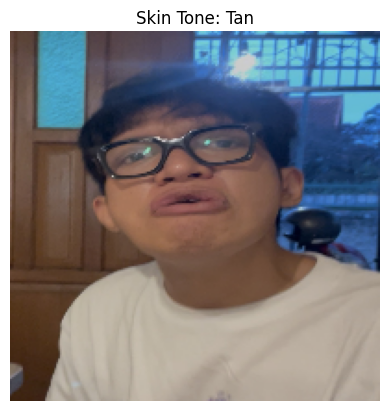

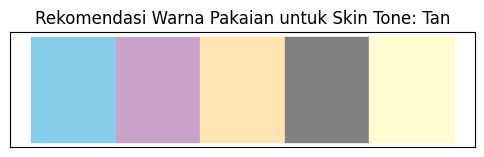

In [ ]:
# --- 🧪 PROSES ---
image = cv2.imread(image_path)
image = cv2.resize(image, (200, 200))
dominant_rgb = get_dominant_color(image)
print("🎨 Dominant RGB:", dominant_rgb)

closest_hex, skin_label = closest_skin_tone(dominant_rgb)
print(f"💄 Skin Tone Terdekat: {skin_label} ({closest_hex})")

recommendations = color_recommendation.get(skin_label, [])
print("👕 Rekomendasi Warna Pakaian:")
for rec in recommendations:
    print(" -", rec)

# --- 🖼️ TAMPILKAN GAMBAR YANG DIUPLOAD ---
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Skin Tone: {skin_label}")
plt.show()

# --- 📦 TAMPILKAN REKOMENDASI WARNA DALAM KOTAK ---
all_colors = []
for c in recommendations:
    if "Neutral:" in c:
        all_colors += [x.strip() for x in c.replace("Neutral:", "").split(',')]
    else:
        all_colors.append(c.strip())

color_boxes = [hex_or_named_color(c) for c in all_colors]
show_color_boxes(color_boxes, f"Rekomendasi Warna Pakaian untuk Skin Tone: {skin_label}")